# Taylor Swift Lyrics Analysis

This notebook explores patterns in Taylor Swift lyrics across songs, albums, and eras. The analysis moves from descriptive language trends to network structure and then to unsupervised and supervised machine-learning models built from lyric text.


## Load Packages and Corpus Data

The opening setup imports the libraries used throughout the notebook and prepares the lyric dataset for downstream analysis.


In [1]:
import pandas as pd
import nltk
import spacy
from nltk.probability import ConditionalFreqDist
import matplotlib.pyplot as plt

ts_full = pd.read_csv('taylor_swift_lyrics.csv', encoding='iso-8859-1')

# Make sure year is numeric and sorted
ts = ts_full.copy()
ts["year"] = pd.to_numeric(ts["year"], errors="coerce")
ts = ts.dropna(subset=["year", "lyric"])
ts["year"] = ts["year"].astype(int)
ts = ts.sort_values("year")

# Build (year, word) pairs
cond_samples = []
for _, row in ts.iterrows():
    words = nltk.word_tokenize(str(row["lyric"]).lower())
    cond_samples.extend((row["year"], w) for w in words)

cfd = ConditionalFreqDist(cond_samples)
years = sorted(cfd.conditions())


## Word Frequency Trends Over Time

These cells track how selected words rise or fall across years. This provides a simple first look at changing lyrical emphasis across the discography.


In [2]:
# 1) Single word trend (gold)
gold_by_year = {y: cfd[y]["gold"] for y in years}
gold_series = pd.Series(gold_by_year).sort_index()
print(gold_series)

2006    0
2008    1
2010    0
2012    0
2014    0
2017    2
dtype: int64


In [3]:
# 2) Multi-word trends
target_words = ["gold", "red", "blue", "love", "night"]
word_trends = pd.DataFrame(
    {w: [cfd[y][w] for y in years] for w in target_words},
    index=years
)
print(word_trends.head())

      gold  red  blue  love  night
2006     0    0     6    17      7
2008     1    0     0    15      9
2010     0    0     1    23     15
2012     0   11     5    25     19
2014     0    7     1    62     11


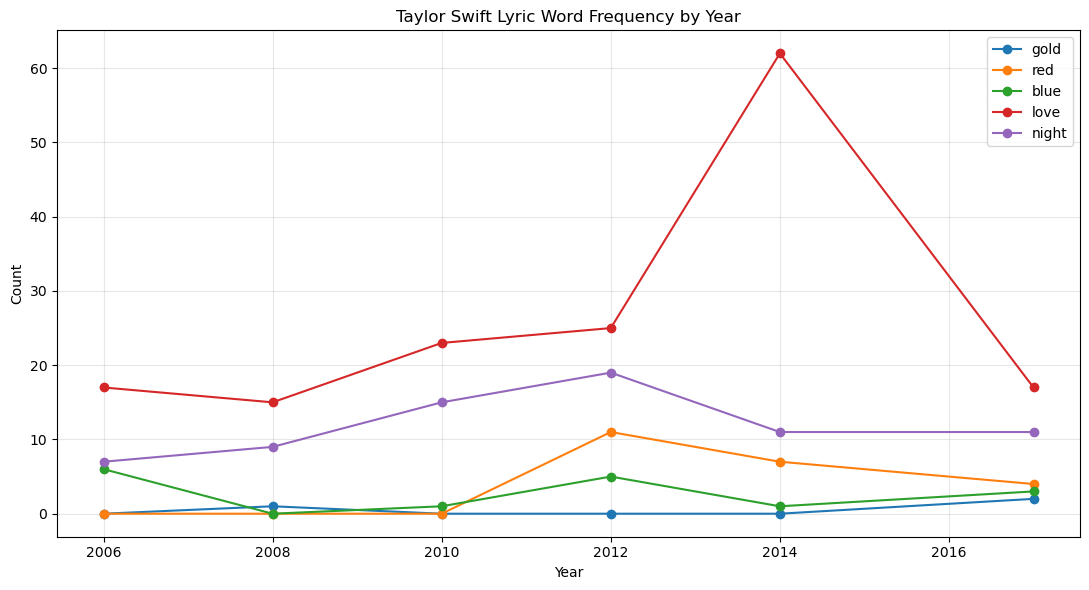

In [4]:
# 3) Plot
ax = word_trends.plot(figsize=(11, 6), marker="o")
ax.set_title("Taylor Swift Lyric Word Frequency by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Pronoun Usage and Narrative Perspective

Pronouns can reveal shifts in narrative voice, relationship framing, and collective versus individual perspective. The next section measures those patterns over time.


In [5]:
import re

# 1) Build one row per song
song_df = (
    ts_full.dropna(subset=["lyric"])
    .groupby(["artist", "album", "track_title", "year"], as_index=False)["lyric"]
    .apply(lambda s: " ".join(s.astype(str)))
)

# 2) Tokenize
song_df["tokens"] = song_df["lyric"].str.lower().str.findall(r"[a-z']+")
song_df["token_count"] = song_df["tokens"].str.len()

# 3) Pronoun counting helper
def count_terms(tokens, terms):
    term_set = set(terms)
    return sum(1 for t in tokens if t in term_set)

I_TERMS = {"i", "i'm", "i've", "i'll", "i'd", "me", "my", "mine", "myself"}
YOU_TERMS = {"you", "you're", "you've", "you'll", "you'd", "your", "yours", "yourself", "yourselves"}
WE_TERMS = {"we", "we're", "we've", "we'll", "we'd", "us", "our", "ours", "ourselves"}
HE_TERMS = {"he", "him", "his", "himself"}
SHE_TERMS = {"she", "her", "hers", "herself"}
THEY_TERMS = {"they", "them", "their", "theirs", "themself", "themselves"}

# 4) Requested columns
song_df["SPEAKER_I"] = song_df["tokens"].apply(lambda t: count_terms(t, I_TERMS))
song_df["ADDRESSEE_YOU"] = song_df["tokens"].apply(lambda t: count_terms(t, YOU_TERMS))
song_df["WE_GROUP"] = song_df["tokens"].apply(lambda t: count_terms(t, WE_TERMS))

# Per-song splits
song_df["HE_1"] = song_df["tokens"].apply(lambda t: count_terms(t, HE_TERMS))
song_df["SHE_1"] = song_df["tokens"].apply(lambda t: count_terms(t, SHE_TERMS))
song_df["THEY_1"] = song_df["tokens"].apply(lambda t: count_terms(t, THEY_TERMS))

song_df.head()


,artist,album,track_title,year,lyric,tokens,token_count,SPEAKER_I,ADDRESSEE_YOU,WE_GROUP,HE_1,SHE_1,THEY_1
0,Taylor Swift,1989,All You Had to Do Was Stay,2014,People like you always want back The love they...,"[people, like, you, always, want, back, the, l...",460,22,54,1,0,0,2
1,Taylor Swift,1989,Bad Blood,2014,"'Cause baby, now we've got bad blood You know ...","['cause, baby, now, we've, got, bad, blood, yo...",472,14,34,26,0,0,2
2,Taylor Swift,1989,Blank Space,2014,"Nice to meet you, where you been? I could show...","[nice, to, meet, you, where, you, been, i, cou...",508,38,36,9,0,1,0
3,Taylor Swift,1989,Clean,2014,The drought was the very worst When the flower...,"[the, drought, was, the, very, worst, when, th...",277,31,8,2,0,0,0
4,Taylor Swift,1989,How You Get The Girl,2014,"Uh, uh, uh Uh, uh, uh Uh-uh, uh-uh Stand there...","[uh, uh, uh, uh, uh, uh, uh, uh, uh, uh, stand...",394,16,30,0,0,5,0


In [6]:
pronoun_cols = ["SPEAKER_I", "ADDRESSEE_YOU", "WE_GROUP", "HE_1", "SHE_1", "THEY_1"]
for c in pronoun_cols:
    song_df[c + "_per_1000"] = (song_df[c] / song_df["token_count"] * 1000).fillna(0)


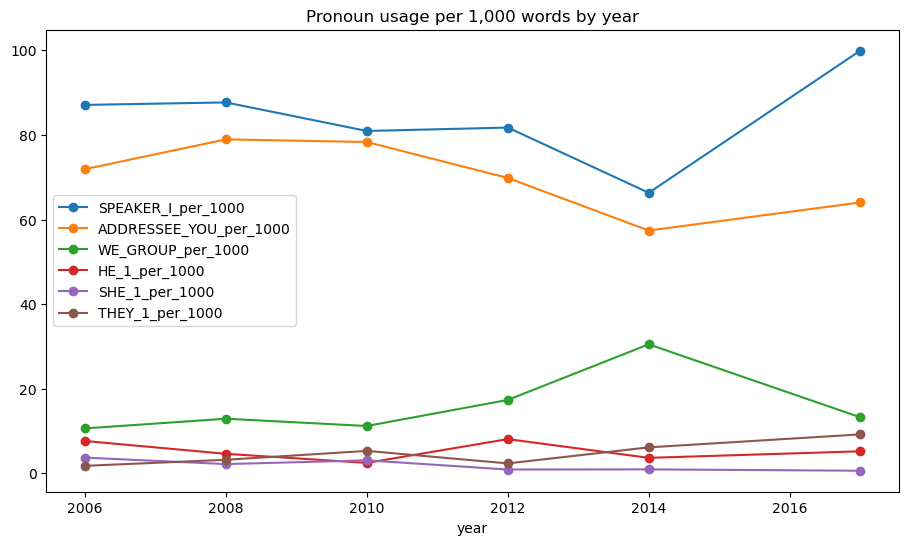

In [7]:
yearly = song_df.groupby("year", as_index=True)[[c + "_per_1000" for c in pronoun_cols]].mean()
yearly.plot(figsize=(11,6), marker="o", title="Pronoun usage per 1,000 words by year");


## Extracting Scene and Setting Language

This stage uses spaCy and custom lexicons to identify concrete places and general settings in the lyrics. The goal is to capture how songs build narrative worlds and physical scenes.


In [8]:
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm")

In [9]:
# Scene lexicon: start small, expand as you inspect outputs
SCENE_NOUNS = {
    "bar","car","kitchen","hallway","bedroom","bathroom","living room","apartment",
    "house","home","street","road","highway","sidewalk","porch","garden","yard",
    "school","church","hotel","motel","restaurant","cafe","diner","club","party",
    "beach","ocean","sea","river","lake","park","city","town","suburb","room",
    "doorway","window","staircase","parking lot","train","station","airport"
}

PLACE_LABELS = {"GPE", "LOC", "FAC"}

def extract_setting_nodes(text):
    doc = nlp(text)

    # Tier 1: specific places via NER
    specific_places = sorted({
        ent.text.strip()
        for ent in doc.ents
        if ent.label_ in PLACE_LABELS and ent.text.strip()
    })

    # Tier 2: generic settings via noun chunks + head nouns
    generic = []
    for chunk in doc.noun_chunks:
        phrase = chunk.text.lower().strip()
        head = chunk.root.lemma_.lower().strip()

        if phrase in SCENE_NOUNS:
            generic.append(phrase)
        elif head in SCENE_NOUNS:
            generic.append(head)

    generic_settings = sorted(set(generic))
    return specific_places, generic_settings


In [10]:
# Apply per song
song_df["SPECIFIC_PLACE_NODES"], song_df["GENERIC_SETTING_NODES"] = zip(
    *song_df["lyric"].astype(str).apply(extract_setting_nodes)
)

song_df["N_SPECIFIC_PLACES"] = song_df["SPECIFIC_PLACE_NODES"].str.len()
song_df["N_GENERIC_SETTINGS"] = song_df["GENERIC_SETTING_NODES"].str.len()

song_df[[
    "track_title","year","SPECIFIC_PLACE_NODES","GENERIC_SETTING_NODES",
    "N_SPECIFIC_PLACES","N_GENERIC_SETTINGS"
]].head(10)


,track_title,year,SPECIFIC_PLACE_NODES,GENERIC_SETTING_NODES,N_SPECIFIC_PLACES,N_GENERIC_SETTINGS
0,All You Had to Do Was Stay,2014,[],[road],0,1
1,Bad Blood,2014,[],[],0,0
2,Blank Space,2014,[Screaming],[garden],1,1
3,Clean,2014,[],[room],0,1
4,How You Get The Girl,2014,[],[],0,0
5,I Know Places,2014,[],[],0,0
6,I Wish You Would,2014,[],"[car, room, street]",0,3
7,New Romantics,2014,[],"[bathroom, road, train]",0,3
8,Out of the Woods,2014,[],[room],0,1
9,Shake It Off,2014,[],[],0,0


In [11]:
# Top setting nodes across all songs
specific_counts = Counter(
    p for places in song_df["SPECIFIC_PLACE_NODES"] for p in places
)
generic_counts = Counter(
    s for settings in song_df["GENERIC_SETTING_NODES"] for s in settings
)

print("Top specific places:", specific_counts.most_common(20))
print("Top generic settings:", generic_counts.most_common(20))


Top specific places: [('New York', 3), ('Screaming', 1), ('Fade', 1), ('Wildest', 1), ('Wonderland', 1), ('Hallelujah', 1), ('Hollywood', 1), ('Photo', 1), ('Cause', 1), ('London', 1), ('Maserati', 1), ('Achilles', 1), ('Madison Square', 1), ('Wearing', 1), ('Forever', 1), ('La', 1), ('la', 1), ('A.M.', 1), ('Drew', 1), ('Hoping', 1)]
Top generic settings: [('room', 20), ('car', 12), ('town', 12), ('street', 11), ('road', 10), ('city', 6), ('window', 6), ('party', 5), ('house', 5), ('school', 4), ('home', 4), ('garden', 3), ('bar', 3), ('bathroom', 2), ('train', 2), ('staircase', 2), ('kitchen', 2), ('doorway', 1), ('bedroom', 1), ('cafe', 1)]


## Pronoun-Setting Network Analysis

The notebook then constructs a network linking pronoun categories and setting terms. This helps identify which perspectives and places tend to co-occur across the corpus and within albums.


In [12]:
import networkx as nx
from collections import Counter


In [13]:
PRONOUN_COLS = ["SPEAKER_I", "ADDRESSEE_YOU", "WE_GROUP", "HE_1", "SHE_1", "THEY_1"]

# Ensure we have one list of setting nodes per song
song_df["ALL_SETTING_NODES"] = song_df.apply(
    lambda r: sorted(set(r["SPECIFIC_PLACE_NODES"] + r["GENERIC_SETTING_NODES"])),
    axis=1
)

G = nx.Graph()

for _, row in song_df.iterrows():
    # only pronoun roles that appear in this song
    active_pronouns = [p for p in PRONOUN_COLS if row.get(p, 0) > 0]
    settings = row["ALL_SETTING_NODES"]

    for p in active_pronouns:
        G.add_node(p, node_type="pronoun")
    for s in settings:
        G.add_node(s, node_type="setting")

    # co-occurrence edges (within-song)
    for p in active_pronouns:
        for s in settings:
            if G.has_edge(p, s):
                G[p][s]["weight"] += 1
            else:
                G.add_edge(p, s, weight=1)


In [14]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# strongest links
top_edges = sorted(G.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)[:20]
top_edges[:10]


Nodes: 64
Edges: 249


[('SPEAKER_I', 'room', {'weight': 20}),
 ('ADDRESSEE_YOU', 'room', {'weight': 20}),
 ('WE_GROUP', 'room', {'weight': 14}),
 ('SPEAKER_I', 'car', {'weight': 12}),
 ('SPEAKER_I', 'town', {'weight': 12}),
 ('ADDRESSEE_YOU', 'town', {'weight': 12}),
 ('SPEAKER_I', 'street', {'weight': 11}),
 ('ADDRESSEE_YOU', 'car', {'weight': 11}),
 ('ADDRESSEE_YOU', 'street', {'weight': 11}),
 ('SPEAKER_I', 'road', {'weight': 10})]

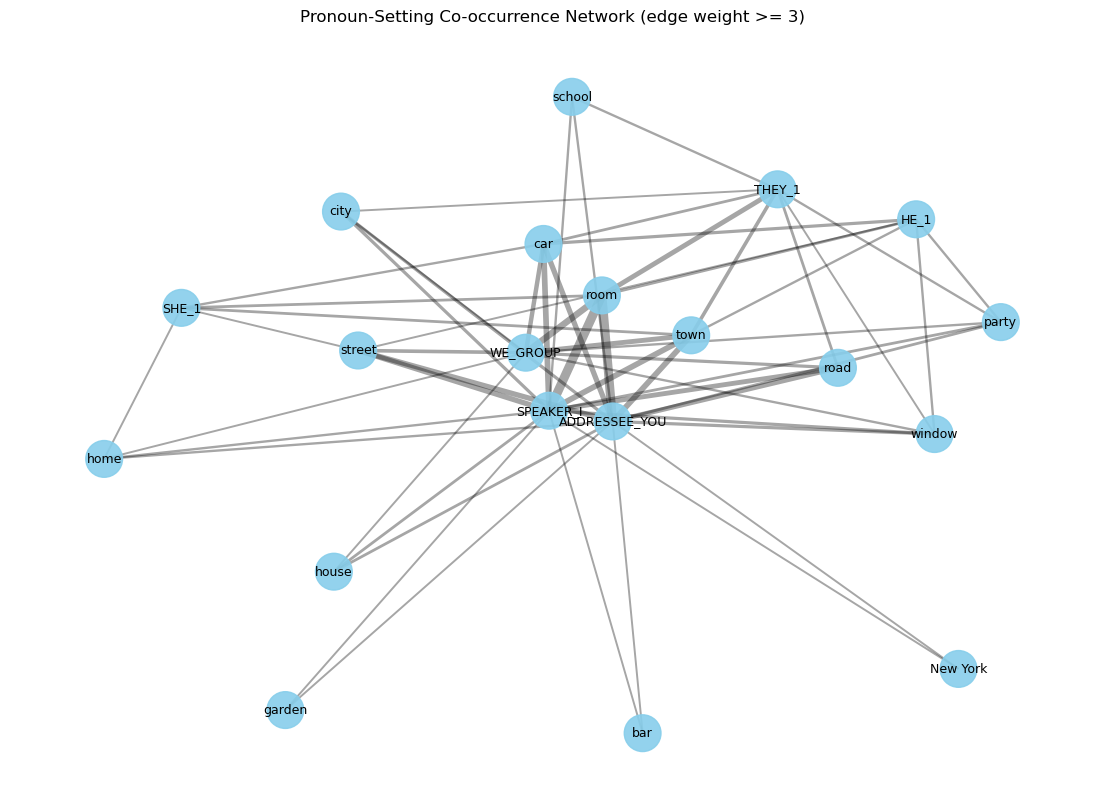

In [15]:
# Prune weak edges for cleaner plot
MIN_WEIGHT = 3
H = nx.Graph(((u, v, d) for u, v, d in G.edges(data=True) if d["weight"] >= MIN_WEIGHT))

node_colors = []
for n in H.nodes:
    node_colors.append("tomato" if H.nodes[n].get("node_type") == "pronoun" else "skyblue")

edge_widths = [0.5 + H[u][v]["weight"] * 0.3 for u, v in H.edges]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(H, k=0.8, seed=42)
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=700, alpha=0.9)
nx.draw_networkx_edges(H, pos, width=edge_widths, alpha=0.35)
nx.draw_networkx_labels(H, pos, font_size=9)
plt.title(f"Pronoun-Setting Co-occurrence Network (edge weight >= {MIN_WEIGHT})")
plt.axis("off")
plt.show()


In [16]:
PRONOUN_COLS = ["SPEAKER_I", "ADDRESSEE_YOU", "WE_GROUP", "HE_1", "SHE_1", "THEY_1"]

def build_pronoun_setting_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        active_pronouns = [p for p in PRONOUN_COLS if row.get(p, 0) > 0]
        settings = row["ALL_SETTING_NODES"] if "ALL_SETTING_NODES" in row else []
        settings = sorted(set(settings))

        for p in active_pronouns:
            G.add_node(p, node_type="pronoun")
        for s in settings:
            G.add_node(s, node_type="setting")

        for p in active_pronouns:
            for s in settings:
                if G.has_edge(p, s):
                    G[p][s]["weight"] += 1
                else:
                    G.add_edge(p, s, weight=1)
    return G

def weighted_degree_df(G):
    rows = []
    for n, d in G.nodes(data=True):
        wdeg = G.degree(n, weight="weight")
        rows.append({"node": n, "node_type": d.get("node_type"), "weighted_degree": wdeg})
    return pd.DataFrame(rows).sort_values("weighted_degree", ascending=False)

def centrality_table(G):
    if G.number_of_nodes() == 0:
        return pd.DataFrame(columns=["node","node_type","weighted_degree","betweenness","eigenvector"])

    wdeg = dict(G.degree(weight="weight"))
    btw = nx.betweenness_centrality(G, weight="weight", normalized=True)
    try:
        eig = nx.eigenvector_centrality_numpy(G, weight="weight")
    except Exception:
        eig = {n: float("nan") for n in G.nodes()}

    rows = []
    for n, d in G.nodes(data=True):
        rows.append({
            "node": n,
            "node_type": d.get("node_type"),
            "weighted_degree": wdeg.get(n, 0),
            "betweenness": btw.get(n, 0),
            "eigenvector": eig.get(n, float("nan"))
        })
    return pd.DataFrame(rows).sort_values(
        ["weighted_degree", "betweenness"], ascending=False
    )



In [17]:
# 1) Centrality rankings for full corpus
G_all = build_pronoun_setting_graph(song_df)
central_all = centrality_table(G_all)

print("Top nodes overall:")
display(central_all.head(20))

print("Top setting nodes:")
display(central_all[central_all["node_type"]=="setting"].head(20))

print("Top pronoun nodes:")
display(central_all[central_all["node_type"]=="pronoun"].head(20))


Top nodes overall:


,node,node_type,weighted_degree,betweenness,eigenvector
0,SPEAKER_I,pronoun,152,0.218954,0.417065
1,ADDRESSEE_YOU,pronoun,150,0.205349,0.412380
2,WE_GROUP,pronoun,105,0.170813,0.291803
8,room,setting,74,0.000000,0.417154
3,THEY_1,pronoun,71,0.091836,0.198835
13,HE_1,pronoun,54,0.215333,0.135613
18,town,setting,50,0.000000,0.268241
9,car,setting,47,0.000000,0.251765
5,SHE_1,pronoun,41,0.135472,0.113685
10,street,setting,37,0.000000,0.214816


Top setting nodes:


,node,node_type,weighted_degree,betweenness,eigenvector
8,room,setting,74,0.000000,0.417154
18,town,setting,50,0.000000,0.268241
9,car,setting,47,0.000000,0.251765
10,street,setting,37,0.000000,0.214816
4,road,setting,33,0.000000,0.197344
23,window,setting,24,0.000000,0.129051
24,party,setting,24,0.000000,0.120032
17,city,setting,20,0.002704,0.116862
26,house,setting,18,0.000000,0.100904
28,school,setting,17,0.000000,0.085554


Top pronoun nodes:


,node,node_type,weighted_degree,betweenness,eigenvector
0,SPEAKER_I,pronoun,152,0.218954,0.417065
1,ADDRESSEE_YOU,pronoun,150,0.205349,0.412380
2,WE_GROUP,pronoun,105,0.170813,0.291803
3,THEY_1,pronoun,71,0.091836,0.198835
13,HE_1,pronoun,54,0.215333,0.135613
5,SHE_1,pronoun,41,0.135472,0.113685


In [18]:
# 2) Album-by-album comparison
album_rows = []
album_graphs = {}

for album, sdf in song_df.groupby("album"):
    G_album = build_pronoun_setting_graph(sdf)
    album_graphs[album] = G_album

    if G_album.number_of_nodes() == 0:
        continue

    ctab = centrality_table(G_album)
    top_setting = ctab[ctab["node_type"]=="setting"]["node"].head(1)
    top_pronoun = ctab[ctab["node_type"]=="pronoun"]["node"].head(1)

    album_rows.append({
        "album": album,
        "songs": len(sdf),
        "nodes": G_album.number_of_nodes(),
        "edges": G_album.number_of_edges(),
        "density": nx.density(G_album) if G_album.number_of_nodes() > 1 else 0,
        "top_setting": top_setting.iloc[0] if len(top_setting) else None,
        "top_pronoun": top_pronoun.iloc[0] if len(top_pronoun) else None
    })

album_summary = pd.DataFrame(album_rows).sort_values("edges", ascending=False)
display(album_summary)


,album,songs,nodes,edges,density,top_setting,top_pronoun
2,Red,19,29,84,0.206897,room,SPEAKER_I
1,Fearless,13,22,75,0.324675,town,SPEAKER_I
3,Speak Now,17,25,74,0.246667,room,SPEAKER_I
4,Taylor Swift,14,22,69,0.298701,window,SPEAKER_I
5,reputation,15,21,65,0.309524,room,SPEAKER_I
0,1989,16,20,56,0.294737,room,SPEAKER_I


In [19]:
# Compare centrality values for selected settings/pronouns across albums
# Edit these to what you care about
focus_nodes = ["SPEAKER_I", "ADDRESSEE_YOU", "WE_GROUP", "new york", "bar", "car", "home"]

comp_rows = []
for album, G_album in album_graphs.items():
    ctab = centrality_table(G_album).set_index("node")
    for node in focus_nodes:
        if node in ctab.index:
            comp_rows.append({
                "album": album,
                "node": node,
                "node_type": ctab.loc[node, "node_type"],
                "weighted_degree": ctab.loc[node, "weighted_degree"],
                "betweenness": ctab.loc[node, "betweenness"],
                "eigenvector": ctab.loc[node, "eigenvector"],
            })

album_node_comp = pd.DataFrame(comp_rows)
display(album_node_comp.sort_values(["node", "weighted_degree"], ascending=[True, False]))


,album,node,node_type,weighted_degree,betweenness,eigenvector
9,Red,ADDRESSEE_YOU,pronoun,38,0.208001,0.442444
14,Speak Now,ADDRESSEE_YOU,pronoun,28,0.205716,0.406452
5,Fearless,ADDRESSEE_YOU,pronoun,27,0.096036,0.390914
1,1989,ADDRESSEE_YOU,pronoun,20,0.196394,0.404593
24,reputation,ADDRESSEE_YOU,pronoun,20,0.167787,0.381018
19,Taylor Swift,ADDRESSEE_YOU,pronoun,17,0.233754,0.341215
8,Red,SPEAKER_I,pronoun,38,0.208001,0.442444
13,Speak Now,SPEAKER_I,pronoun,28,0.205716,0.406452
4,Fearless,SPEAKER_I,pronoun,27,0.096036,0.390914
0,1989,SPEAKER_I,pronoun,20,0.196394,0.404593


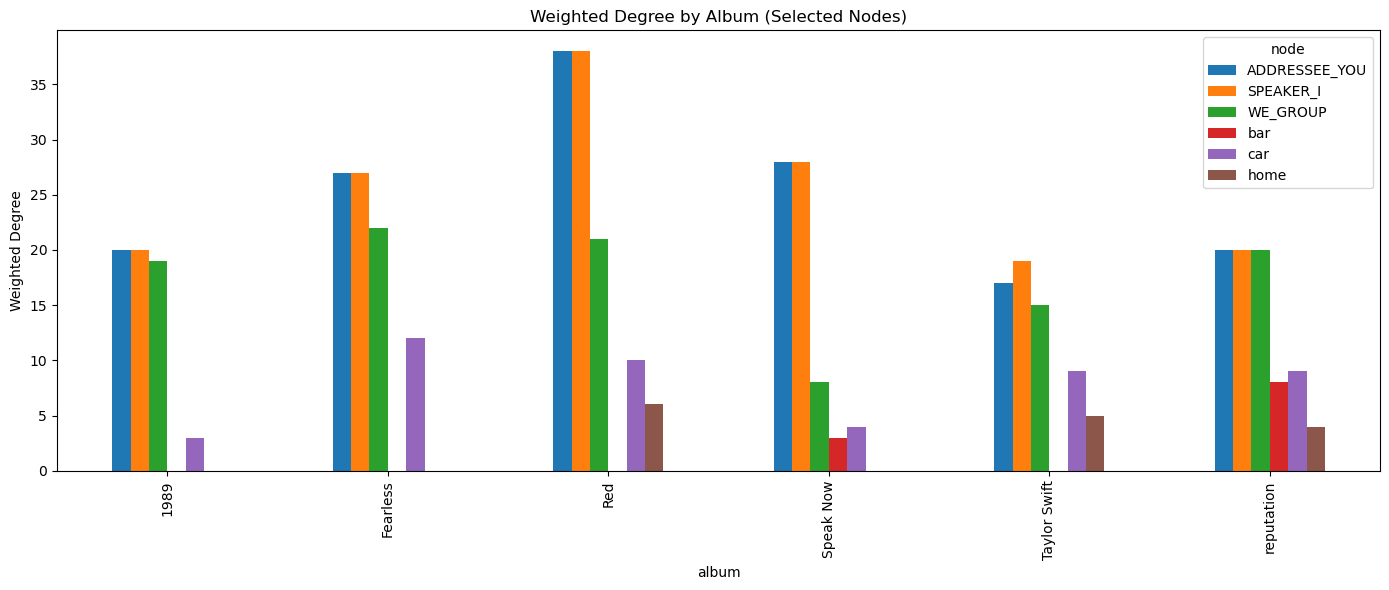

In [20]:
# Quick visualization: weighted degree of focus nodes by album
if not album_node_comp.empty:
    pivot = album_node_comp.pivot(index="album", columns="node", values="weighted_degree").fillna(0)
    pivot.plot(kind="bar", figsize=(14,6))
    plt.title("Weighted Degree by Album (Selected Nodes)")
    plt.ylabel("Weighted Degree")
    plt.tight_layout()
    plt.show()


## Interactive Network Export

These cells export interactive network visualizations so the structure can be explored outside static notebook plots.


In [21]:
from pyvis.network import Network
from pathlib import Path
import re

def slugify(text):
    return re.sub(r"[^a-z0-9]+", "_", text.lower()).strip("_")

def export_album_network_html(album, G_album, out_dir="album_networks", min_weight=1):
    out_path = Path(out_dir)
    out_path.mkdir(exist_ok=True)

    H = nx.Graph((u, v, d) for u, v, d in G_album.edges(data=True) if d.get("weight", 1) >= min_weight)

    net = Network(height="750px", width="100%", bgcolor="white", font_color="black", notebook=True)
    net.force_atlas_2based(gravity=-30, central_gravity=0.01, spring_length=180, spring_strength=0.03)

    for n, d in H.nodes(data=True):
        ntype = d.get("node_type", "unknown")
        color = "#e76f51" if ntype == "pronoun" else "#2a9d8f"
        title = f"{n}<br>type: {ntype}<br>weighted degree: {H.degree(n, weight='weight')}"
        net.add_node(n, label=n, color=color, title=title)

    for u, v, d in H.edges(data=True):
        w = d.get("weight", 1)
        net.add_edge(u, v, value=w, title=f"weight: {w}")

    html_file = out_path / f"{slugify(album)}_network.html"
    net.write_html(str(html_file), notebook=False)
    return str(html_file)


In [22]:
# Build + export all album HTMLs
html_files = []
for album, sdf in song_df.groupby("album"):
    G_album = build_pronoun_setting_graph(sdf)
    if G_album.number_of_edges() == 0:
        continue
    html_files.append((album, export_album_network_html(album, G_album, min_weight=2)))

html_files[:10]


[('1989', 'album_networks/1989_network.html'),
 ('Fearless', 'album_networks/fearless_network.html'),
 ('Red', 'album_networks/red_network.html'),
 ('Speak Now', 'album_networks/speak_now_network.html'),
 ('Taylor Swift', 'album_networks/taylor_swift_network.html'),
 ('reputation', 'album_networks/reputation_network.html')]

In [23]:
# Show one directly in notebook
from IPython.display import IFrame, display

album_to_view = html_files[0][0] if html_files else None
if album_to_view:
    html_path = dict(html_files)[album_to_view]
    display(IFrame(src=html_path, width="100%", height=800))


## Build Text Features for Modeling

Before modeling, the lyrics are transformed into numerical representations such as TF-IDF features and sentiment-oriented variables. These features support topic modeling, clustering, and classification.


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

album_text = (ts_full.dropna(subset=["lyric"])
              .groupby("album")["lyric"].apply(lambda s: " ".join(s.astype(str))).reset_index())

vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)
X = vec.fit_transform(album_text["lyric"])
terms = vec.get_feature_names_out()

for i, album in enumerate(album_text["album"]):
    top = X[i].toarray().ravel().argsort()[-12:][::-1]
    print(album, "=>", [terms[j] for j in top])


1989 => ['shake', 'clear', 'wish', 'love', 'got', 'new', 'wish wish', 'york', 'welcome', 'new york', 'oh', 'baby']
Fearless => ['know', 'la', 'la la', 'don', 'mm', 'oh', 'help', 'like', 'll', 'belong', 'cause', 'feel']
Red => ['like', 'ooh', 'know', 'ooh ooh', 'oh', 'time', 'stay stay', 'oh oh', 'just', 'don', 'asking', 'know better']
Speak Now => ['don', 'like', 'll', 'know', 'just', 'oh', 'say', 'time', 'come', 'mean', 'love', 'thought']
Taylor Swift => ['know', 've', 'oh', 'just', 'don', 'think', 'wanna', 'said', 'beautiful', 'll', 'hope', 'song']
reputation => ['oh', 'don', 'ha', 'like', 'ah', 'want', 'isn', 'ooh', 'look', 'just', 'want want', 'wanna']


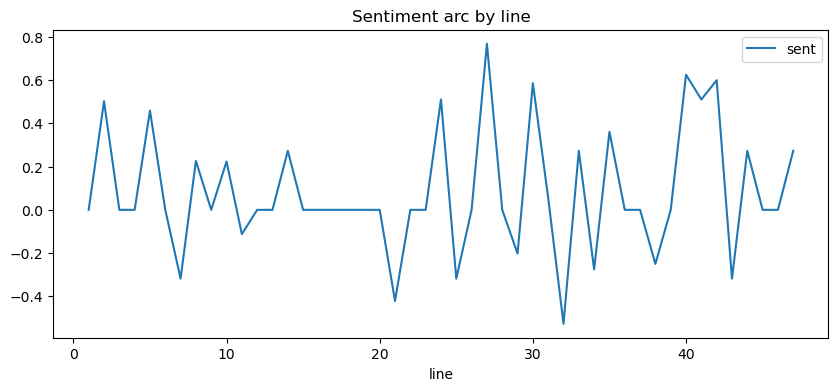

In [25]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

line_df = ts_full.dropna(subset=["lyric"]).copy()
line_df["sent"] = line_df["lyric"].astype(str).apply(lambda x: sia.polarity_scores(x)["compound"])

song_arc = (line_df.groupby(["album","track_title","line"], as_index=False)["sent"].mean())
# pick one song to visualize
s = song_arc[song_arc["track_title"]=="All Too Well"]
s.plot(x="line", y="sent", figsize=(10,4), title="Sentiment arc by line");


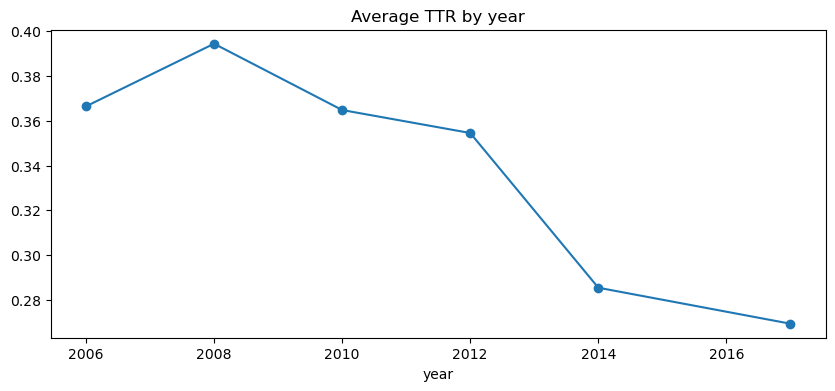

In [26]:
import numpy as np

song = (ts_full.dropna(subset=["lyric"])
        .groupby(["album","track_title","year"], as_index=False)["lyric"]
        .apply(lambda s: " ".join(s.astype(str))))
song["tokens"] = song["lyric"].str.lower().str.findall(r"[a-z']+")
song["n_tokens"] = song["tokens"].str.len()
song["n_types"] = song["tokens"].apply(lambda t: len(set(t)))
song["ttr"] = song["n_types"] / song["n_tokens"].replace(0, np.nan)

song.groupby("year")["ttr"].mean().plot(marker="o", figsize=(10,4), title="Average TTR by year");


## scikit-learn Lyric Modeling

The next section applies several scikit-learn models to the lyric corpus. The models are used for theme extraction, song grouping, and album prediction.


## scikit-learn lyric modeling

This section adds three models to better understand lyric structure at the **song** level:
- NMF topic modeling (interpretable themes)
- KMeans clustering (song groupings)
- Logistic Regression (album prediction from lyrics)


In [27]:
from sklearn.cluster import KMeans
from sklearn.decomposition import NMF
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Build a song-level corpus from line-level lyrics
song_text = (
    ts_full.dropna(subset=['lyric'])
    .groupby(['album', 'track_title', 'year'], as_index=False)['lyric']
    .apply(lambda s: ' '.join(s.astype(str)))
)

# Reduce filler tokens that dominate lyric corpora
filler_stopwords = {'oh', 'yeah', 'la', 'haha', 'ha', 'uh', 'ooh', 'na'}
custom_stop_words = sorted(set(TfidfVectorizer(stop_words='english').get_stop_words()).union(filler_stopwords))

song_vec = TfidfVectorizer(
    stop_words=custom_stop_words,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.8
)
X_song = song_vec.fit_transform(song_text['lyric'])
terms = song_vec.get_feature_names_out()

print('Songs:', X_song.shape[0], '| Features:', X_song.shape[1])


Songs: 94 | Features: 675


### 1) NMF topic modeling
Use NMF on TF-IDF to extract interpretable lyric themes.


In [28]:
n_topics = min(8, max(2, min(X_song.shape[0] - 1, X_song.shape[1] - 1)))
nmf = NMF(n_components=n_topics, random_state=42, init='nndsvda', max_iter=1000)
W = nmf.fit_transform(X_song)
H = nmf.components_

topic_strength = H.sum(axis=1)
if (topic_strength <= 1e-12).any():
    weak = [i + 1 for i, v in enumerate(topic_strength) if v <= 1e-12]
    print('Warning: near-zero topic(s) detected:', weak)

top_n = 12
for topic_idx, topic in enumerate(H, start=1):
    top_idx = topic.argsort()[-top_n:][::-1]
    top_terms = [terms[i] for i in top_idx]
    print(f'Topic {topic_idx}:', ', '.join(top_terms))

song_text['nmf_topic'] = W.argmax(axis=1) + 1
song_text[['album', 'track_title', 'nmf_topic']].head()


Topic 1: know, don know, want, better, don, girl, just, just want, like, run, trying, places
Topic 2: wanna, don wanna, don, good, dance, game, perfectly, break, heart, big, end, ground
Topic 3: come, come come, new, new york, york, help, like, don wanna, day, busy, feeling, way
Topic 4: ve, said, time, got, asking, did, baby, sorry, cause, remember, gone, ve got
Topic 5: stay, mad, beautiful, hey, time time, don, want just, want, little, time, darling, wish
Topic 6: dancing, like, dancing like, hands, dancing dancing, dream, night, forget, dressed, best, dance, nights
Topic 7: think, whoa, ah, nice, car, follow, known, dress, hope, don think, things, like
Topic 8: ll, love, don, beautiful, meet, feel, baby, fly, say, way, forever, save


,album,track_title,nmf_topic
0,1989,All You Had to Do Was Stay,5
1,1989,Bad Blood,4
2,1989,Blank Space,8
3,1989,Clean,7
4,1989,How You Get The Girl,1


### 2) KMeans clustering
Cluster songs by lyric similarity, then inspect album composition by cluster.


In [29]:
n_clusters = min(8, max(2, X_song.shape[0] // 15))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
song_text['cluster'] = kmeans.fit_predict(X_song)

cluster_album = (song_text.groupby(['cluster', 'album'])['track_title']
                 .count()
                 .rename('song_count')
                 .reset_index()
                 .sort_values(['cluster', 'song_count'], ascending=[True, False]))

cluster_album.head(20)


,cluster,album,song_count
1,0,Red,3
0,0,1989,2
2,0,reputation,2
5,1,Red,4
4,1,Fearless,3
6,1,Speak Now,3
8,1,reputation,2
3,1,1989,1
7,1,Taylor Swift,1
11,2,Red,5


### 3) Album prediction with Logistic Regression
Train a linear classifier to identify albums from lyrics and inspect predictive n-grams.


In [30]:
min_songs_per_album = 3
album_counts = song_text['album'].value_counts()
model_df = song_text[song_text['album'].isin(album_counts[album_counts >= min_songs_per_album].index)].copy()

X_model = song_vec.transform(model_df['lyric'])
y_model = model_df['album']

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.25, random_state=42, stratify=y_model
)

log_reg = LogisticRegression(max_iter=3000, class_weight='balanced', multi_class='auto')
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, zero_division=0))

# Top album-signature terms from learned coefficients
coef_df = pd.DataFrame(log_reg.coef_, index=log_reg.classes_, columns=terms)
top_terms_by_album = {}
for album in coef_df.index:
    top_terms_by_album[album] = coef_df.loc[album].sort_values(ascending=False).head(12).index.tolist()

pd.DataFrame({'album': list(top_terms_by_album.keys()), 'top_terms': list(top_terms_by_album.values())})


Accuracy: 0.125
              precision    recall  f1-score   support

        1989       0.00      0.00      0.00         4
    Fearless       1.00      0.33      0.50         3
         Red       0.14      0.20      0.17         5
   Speak Now       0.12      0.25      0.17         4
Taylor Swift       0.00      0.00      0.00         4
  reputation       0.00      0.00      0.00         4

    accuracy                           0.12        24
   macro avg       0.21      0.13      0.14        24
weighted avg       0.18      0.12      0.12        24



/Users/bajeeramccorkle/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,album,top_terms
0,1989,"[clear, shake, love, places, stay, forever, fr..."
1,Fearless,"[sorry, help, know, going, sorry sorry, town, ..."
2,Red,"[follow, bet, asking, walked, everybody, time,..."
3,Speak Now,"[mean, thought, mind, come come, don think, so..."
4,Taylor Swift,"[beautiful, song, outside, said, ve, smile, un..."
5,reputation,"[isn, ah, hold, car, goes, games, whoa, dancin..."


## Model Visualizations

These plots summarize the output of the text models, including topic prevalence, cluster sizes, and classifier performance.


### Model Visualizations

1. Topic prevalence by album
2. Cluster sizes
3. Album confusion matrix


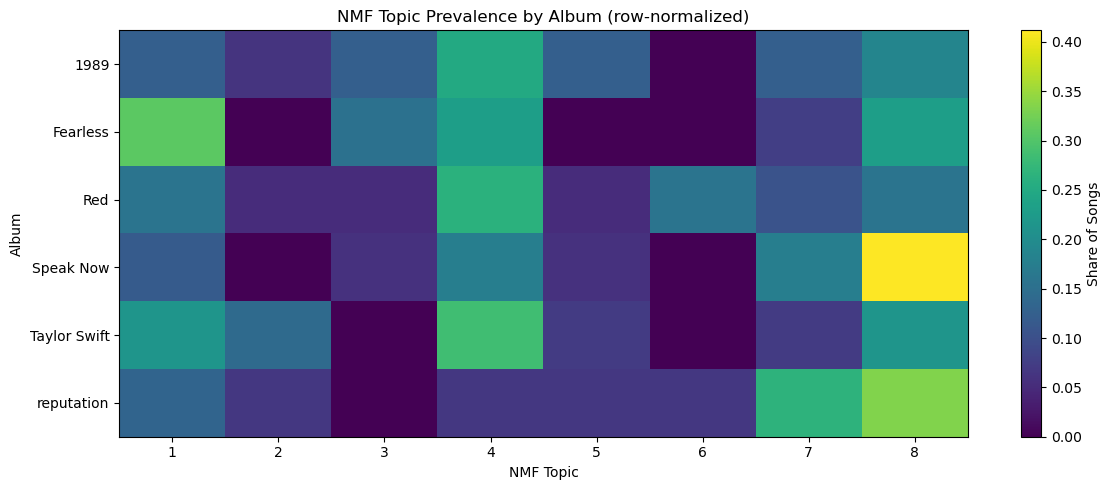

In [31]:
# 1) Topic prevalence by album (row-normalized heatmap-like chart)
topic_album = pd.crosstab(song_text['album'], song_text['nmf_topic'], normalize='index')

fig, ax = plt.subplots(figsize=(12, max(5, 0.4 * len(topic_album))))
im = ax.imshow(topic_album.values, aspect='auto')
ax.set_title('NMF Topic Prevalence by Album (row-normalized)')
ax.set_xlabel('NMF Topic')
ax.set_ylabel('Album')
ax.set_xticks(range(topic_album.shape[1]))
ax.set_xticklabels(topic_album.columns)
ax.set_yticks(range(topic_album.shape[0]))
ax.set_yticklabels(topic_album.index)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Share of Songs')
plt.tight_layout()
plt.show()


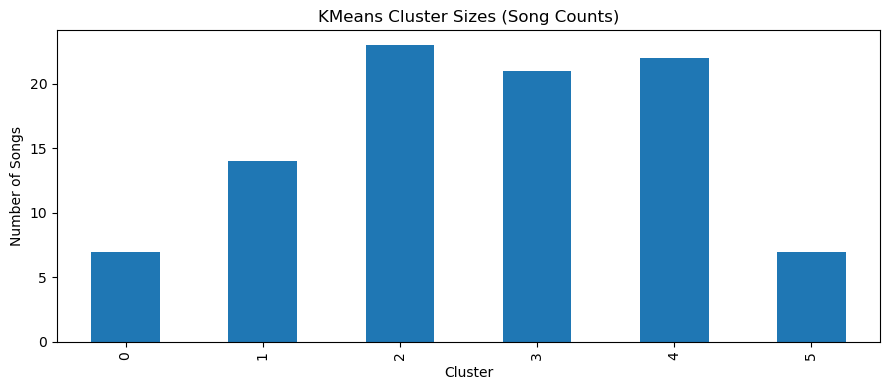

cluster
0     7
1    14
2    23
3    21
4    22
5     7
Name: count, dtype: int64

In [32]:
# 2) Cluster sizes
cluster_sizes = song_text['cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
cluster_sizes.plot(kind='bar', ax=ax)
ax.set_title('KMeans Cluster Sizes (Song Counts)')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Songs')
plt.tight_layout()
plt.show()

cluster_sizes


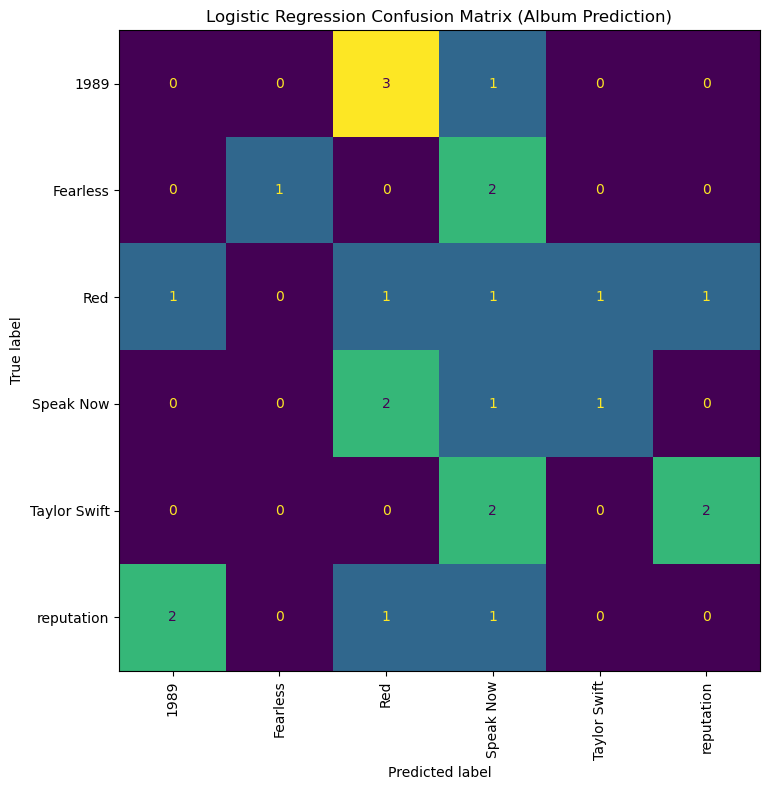

In [33]:
# 3) Confusion matrix for album classifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
ax.set_title('Logistic Regression Confusion Matrix (Album Prediction)')
plt.tight_layout()
plt.show()


## NMF Tuning and Stability Checks

Because topic-model results depend on the number of topics and random initialization, this section evaluates alternative NMF specifications and checks whether the discovered themes remain stable.


### NMF Tuning: Topic Count + Stability

This section reduces arbitrariness by evaluating NMF across:
- multiple `n_components` values
- multiple random seeds per topic count

We compare:
- reconstruction error (lower is better)
- topic-term stability via average Jaccard overlap of top terms across seeds (higher is better)


In [34]:
from itertools import combinations

def _top_terms_per_topic(model, feature_names, top_n=12):
    top_lists = []
    for topic in model.components_:
        idx = topic.argsort()[-top_n:][::-1]
        top_lists.append([feature_names[i] for i in idx])
    return top_lists

def _topic_stability_jaccard(topics_a, topics_b):
    # Greedy best-match Jaccard overlap between topic sets
    used_b = set()
    scores = []
    for ta in topics_a:
        set_a = set(ta)
        best = -1
        best_j = None
        for j, tb in enumerate(topics_b):
            if j in used_b:
                continue
            set_b = set(tb)
            inter = len(set_a & set_b)
            union = len(set_a | set_b)
            jac = inter / union if union else 0.0
            if jac > best:
                best = jac
                best_j = j
        if best_j is not None:
            used_b.add(best_j)
            scores.append(best)
    return float(np.mean(scores)) if scores else np.nan


In [35]:
k_values = list(range(4, 15))
seeds = [7, 21, 42, 84, 168]
top_n_terms = 12

rows = []
for k in k_values:
    run_topics = {}
    errors = []

    for seed in seeds:
        model = NMF(
            n_components=k,
            init='nndsvda',
            random_state=seed,
            solver='cd',
            beta_loss='frobenius',
            alpha_W=0.0,
            alpha_H=0.0,
            l1_ratio=0.0,
            max_iter=1000
        )
        model.fit(X_song)
        errors.append(model.reconstruction_err_)
        run_topics[seed] = _top_terms_per_topic(model, terms, top_n=top_n_terms)

    pair_scores = []
    for s1, s2 in combinations(seeds, 2):
        pair_scores.append(_topic_stability_jaccard(run_topics[s1], run_topics[s2]))

    rows.append({
        'k': k,
        'mean_reconstruction_error': float(np.mean(errors)),
        'std_reconstruction_error': float(np.std(errors)),
        'mean_stability_jaccard': float(np.mean(pair_scores)),
        'std_stability_jaccard': float(np.std(pair_scores))
    })

nmf_tuning = pd.DataFrame(rows).sort_values('k').reset_index(drop=True)
nmf_tuning


,k,mean_reconstruction_error,std_reconstruction_error,mean_stability_jaccard,std_stability_jaccard
0,4,8.964076,5.301587e-03,0.654224,0.282325
1,5,8.866994,1.506377e-09,1.000000,0.000000
2,6,8.785692,2.903232e-09,1.000000,0.000000
3,7,8.688228,6.386582e-03,0.713823,0.237285
4,8,8.599657,1.650657e-03,0.774570,0.166544
5,9,8.512589,4.662497e-08,0.989744,0.008374
6,10,8.430661,3.037818e-03,0.623854,0.110208
7,11,8.347181,3.287284e-03,0.730610,0.131233
8,12,8.266414,4.082929e-03,0.679332,0.100357
9,13,8.188356,4.637684e-03,0.710392,0.126649


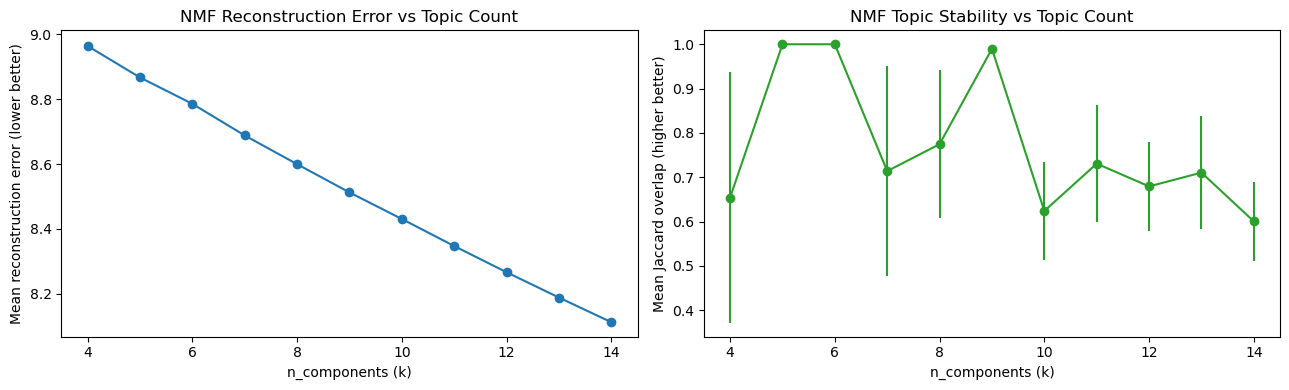

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].errorbar(
    nmf_tuning['k'],
    nmf_tuning['mean_reconstruction_error'],
    yerr=nmf_tuning['std_reconstruction_error'],
    marker='o'
)
axes[0].set_title('NMF Reconstruction Error vs Topic Count')
axes[0].set_xlabel('n_components (k)')
axes[0].set_ylabel('Mean reconstruction error (lower better)')

axes[1].errorbar(
    nmf_tuning['k'],
    nmf_tuning['mean_stability_jaccard'],
    yerr=nmf_tuning['std_stability_jaccard'],
    marker='o',
    color='tab:green'
)
axes[1].set_title('NMF Topic Stability vs Topic Count')
axes[1].set_xlabel('n_components (k)')
axes[1].set_ylabel('Mean Jaccard overlap (higher better)')

plt.tight_layout()
plt.show()


In [37]:
# Simple combined score (normalize each metric to 0-1 and combine)
score_df = nmf_tuning.copy()
err = score_df['mean_reconstruction_error']
stab = score_df['mean_stability_jaccard']

score_df['err_norm'] = (err - err.min()) / (err.max() - err.min() + 1e-12)
score_df['stab_norm'] = (stab - stab.min()) / (stab.max() - stab.min() + 1e-12)
score_df['combined_score'] = (1 - score_df['err_norm']) * 0.5 + score_df['stab_norm'] * 0.5

best_k = int(score_df.sort_values('combined_score', ascending=False).iloc[0]['k'])
print('Suggested k based on equal-weighted error/stability score:', best_k)
score_df.sort_values('combined_score', ascending=False).head(5)


Suggested k based on equal-weighted error/stability score: 9


,k,mean_reconstruction_error,std_reconstruction_error,mean_stability_jaccard,std_stability_jaccard,err_norm,stab_norm,combined_score
5,9,8.512589,4.662497e-08,0.989744,0.008374,0.469892,0.974332,0.752220
2,6,8.785692,2.903232e-09,1.000000,0.000000,0.790552,1.000000,0.604724
9,13,8.188356,4.637684e-03,0.710392,0.126649,0.089199,0.275223,0.593012
1,5,8.866994,1.506377e-09,1.000000,0.000000,0.886013,1.000000,0.556994
7,11,8.347181,3.287284e-03,0.730610,0.131233,0.275681,0.325821,0.525070


In [38]:
# refit final NMF using tuned k and inspect topics
nmf_final = NMF(
    n_components=best_k,
    init='nndsvda',
    random_state=42,
    solver='cd',
    beta_loss='frobenius',
    alpha_W=0.0,
    alpha_H=0.0,
    l1_ratio=0.0,
    max_iter=2000
)
W_final = nmf_final.fit_transform(X_song)
H_final = nmf_final.components_

topic_strength_final = H_final.sum(axis=1)
if (topic_strength_final <= 1e-12).any():
    weak = [i + 1 for i, v in enumerate(topic_strength_final) if v <= 1e-12]
    print('Warning: near-zero topic(s) detected in final model:', weak)

for topic_idx, topic in enumerate(H_final, start=1):
    idx = topic.argsort()[-12:][::-1]
    print(f'Topic {topic_idx}:', ', '.join(terms[i] for i in idx))


Topic 1: know, don know, better, want, don, just want, places, like, run, just, going, bet
Topic 2: wanna, don wanna, don, good, dance, game, perfectly, break, heart, big, end, ground
Topic 3: come, come come, new, york, new york, help, like, don wanna, day, busy, feeling, way
Topic 4: ve, said, time, asking, baby, did, sorry, gone, got, moment, remember, cause
Topic 5: stay, mad, beautiful, hey, time time, don, want, want just, little, darling, time, loving
Topic 6: dancing, like, dancing like, hands, dancing dancing, dream, night, forget, dressed, nights, moved, best
Topic 7: think, ah, whoa, follow, nice, car, dress, known, hope, things, don think, like
Topic 8: love, ll, beautiful, meet, don, feel, baby, way, save, coming, lights, fly
Topic 9: girl, look, got, everybody, goes, knows, ll, just, lucky, tell, home, don


## Neural Extension with Pretrained Embeddings

This extension moves beyond sparse word features by using dense text embeddings and a neural classifier. It offers a complementary view of album-level separability in lyric space.


## Neural Extension: Pretrained Embeddings + MLP

This section uses a pretrained sentence model to embed each song lyric, then trains a compact neural network (`MLPClassifier`) for album prediction.

Why this approach:
- works better on small lyric datasets than training a deep model from scratch
- captures semantics beyond bag-of-words
- embeddings can be reused for similarity and clustering


In [39]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

# Song-level corpus (reuses existing ts_full)
song_nn = (
    ts_full.dropna(subset=['lyric'])
    .groupby(['album', 'track_title', 'year'], as_index=False)['lyric']
    .apply(lambda s: ' '.join(s.astype(str)))
)

# Keep labels with enough samples for stratified split
min_songs_per_album = 3
album_counts = song_nn['album'].value_counts()
song_nn = song_nn[song_nn['album'].isin(album_counts[album_counts >= min_songs_per_album].index)].copy()

encoder_model = SentenceTransformer('all-MiniLM-L6-v2')
X_emb = encoder_model.encode(song_nn['lyric'].tolist(), batch_size=16, show_progress_bar=False)

le = LabelEncoder()
y = le.fit_transform(song_nn['album'])

X_train, X_test, y_train, y_test = train_test_split(
    X_emb, y, test_size=0.25, random_state=42, stratify=y
)

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 64),
    activation='relu',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=12,
    random_state=42
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

print('MLP on embeddings accuracy:', round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MLP on embeddings accuracy: 0.167
              precision    recall  f1-score   support

        1989       0.00      0.00      0.00         4
    Fearless       0.00      0.00      0.00         3
         Red       0.00      0.00      0.00         5
   Speak Now       0.00      0.00      0.00         4
Taylor Swift       0.14      0.75      0.23         4
  reputation       1.00      0.25      0.40         4

    accuracy                           0.17        24
   macro avg       0.19      0.17      0.11        24
weighted avg       0.19      0.17      0.11        24



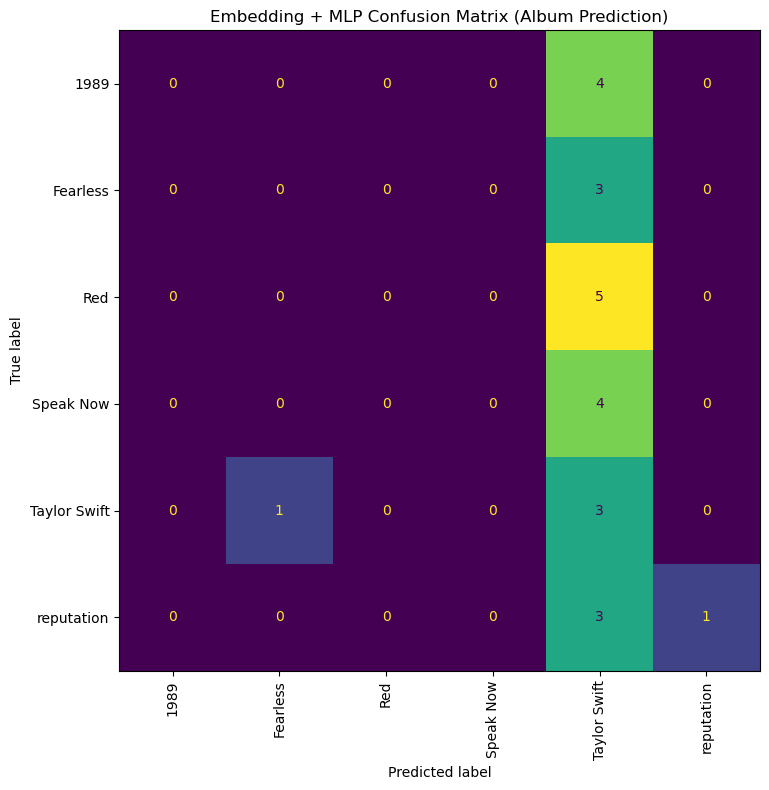

In [40]:
# Confusion matrix for neural classifier
labels_idx = list(range(len(le.classes_)))
cm_nn = confusion_matrix(y_test, y_pred, labels=labels_idx)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=le.classes_)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
ax.set_title('Embedding + MLP Confusion Matrix (Album Prediction)')
plt.tight_layout()
plt.show()


/Users/bajeeramccorkle/anaconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


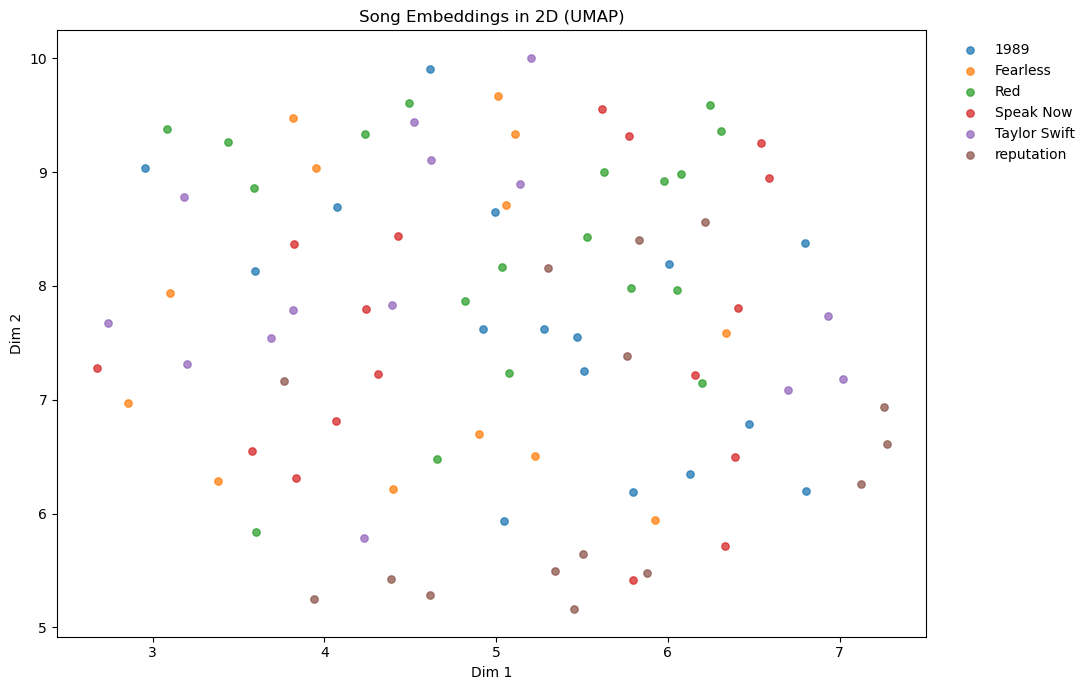

In [41]:
# 2D embedding visualization with UMAP
import umap

reducer = umap.UMAP(n_neighbors=12, min_dist=0.25, metric='cosine', random_state=42)
X_2d = reducer.fit_transform(X_emb)
plot_df = pd.DataFrame({
    'x': X_2d[:, 0],
    'y': X_2d[:, 1],
    'album': song_nn['album'].values
})

fig, ax = plt.subplots(figsize=(11, 7))
for album_name, grp in plot_df.groupby('album'):
    ax.scatter(grp['x'], grp['y'], s=28, alpha=0.75, label=album_name)
ax.set_title('Song Embeddings in 2D (UMAP)')
ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()


In [42]:
# Nearest-song lookup using embedding cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(X_emb)
np.fill_diagonal(sim, -1)

query_idx = 0
top_k = 5
nearest_idx = sim[query_idx].argsort()[-top_k:][::-1]

print('Query song:', song_nn.iloc[query_idx]['track_title'], '|', song_nn.iloc[query_idx]['album'])
print('Most similar songs:')
for j in nearest_idx:
    print('-', song_nn.iloc[j]['track_title'], '|', song_nn.iloc[j]['album'], '| sim=', round(float(sim[query_idx, j]), 3))


Query song: All You Had to Do Was Stay | 1989
Most similar songs:
- Haunted | Speak Now | sim= 0.574
- You're Not Sorry | Fearless | sim= 0.567
- Breathe (Ft. Colbie Caillat) | Fearless | sim= 0.559
- The Last Time (Ft. Gary Lightbody) | Red | sim= 0.557
- This Is Why We Can't Have Nice Things | reputation | sim= 0.542


## Discography Similarity and Era Drift

The final analytical section compares songs and albums in embedding space to study similarity patterns, historical drift, and local neighborhoods of closely related tracks.


## Discography Correlation Tweaks

These additions focus on interpretable discography-level relationships:
- **Album-to-album lyric similarity** (embedding centroid cosine matrix)
- **Era drift**: correlation between year and similarity to the earliest-album style
- **Song similarity visualization** for any selected track


In [43]:
from sklearn.metrics.pairwise import cosine_similarity

# Keep an aligned copy with embedding vectors
song_embed_df = song_nn[['album', 'track_title', 'year']].copy().reset_index(drop=True)
song_embed_df['year'] = pd.to_numeric(song_embed_df['year'], errors='coerce')

# Album centroids in embedding space
album_centroids = (
    pd.DataFrame(X_emb)
    .assign(album=song_embed_df['album'].values)
    .groupby('album', as_index=True)
    .mean()
)

album_sim = cosine_similarity(album_centroids.values)
album_sim_df = pd.DataFrame(album_sim, index=album_centroids.index, columns=album_centroids.index)
album_sim_df


album,1989,Fearless,Red,Speak Now,Taylor Swift,reputation
album,,,,,,
1989,1.000000,0.904668,0.934518,0.915062,0.898602,0.914232
Fearless,0.904668,1.000000,0.926813,0.930684,0.918564,0.885746
Red,0.934518,0.926813,1.000000,0.932124,0.925967,0.908623
Speak Now,0.915062,0.930684,0.932124,1.000000,0.903394,0.905172
Taylor Swift,0.898602,0.918564,0.925967,0.903394,1.000000,0.872200
reputation,0.914232,0.885746,0.908623,0.905172,0.872200,1.000000


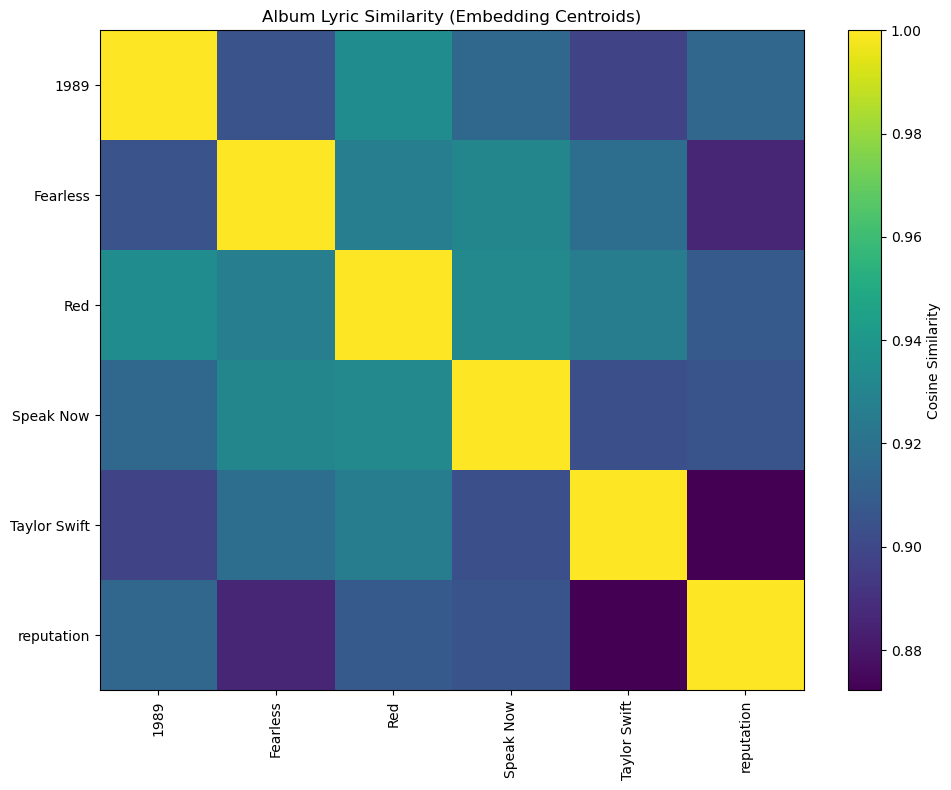

In [44]:
# Album-to-album similarity heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(album_sim_df.values, aspect='auto')
ax.set_title('Album Lyric Similarity (Embedding Centroids)')
ax.set_xticks(range(len(album_sim_df.columns)))
ax.set_xticklabels(album_sim_df.columns, rotation=90)
ax.set_yticks(range(len(album_sim_df.index)))
ax.set_yticklabels(album_sim_df.index)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Cosine Similarity')
plt.tight_layout()
plt.show()


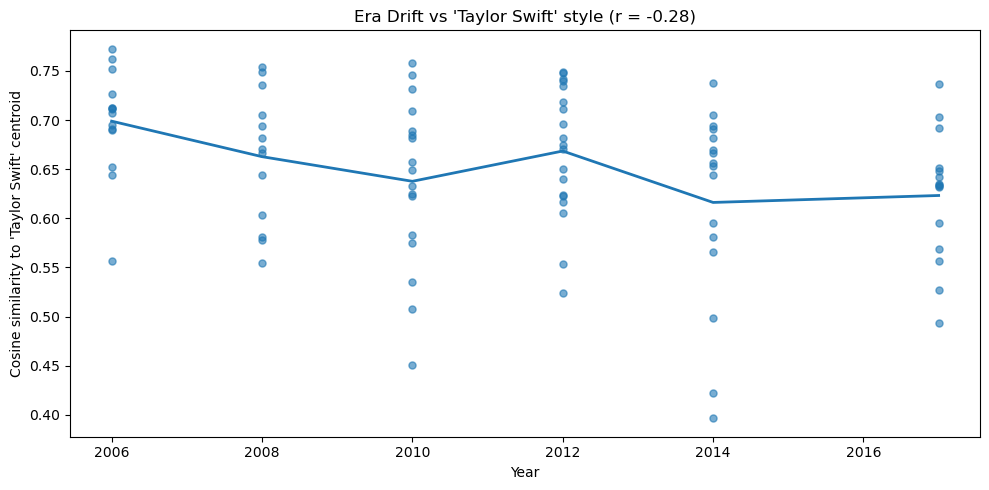

Earliest album used as style anchor: Taylor Swift
Correlation (year vs similarity-to-anchor): -0.285


In [45]:
# Era drift: similarity-to-origin vs year
earliest_album = (song_embed_df[['album', 'year']].dropna().sort_values('year').iloc[0]['album'])
origin_centroid = album_centroids.loc[earliest_album].values.reshape(1, -1)

song_embed_df['sim_to_earliest_album'] = cosine_similarity(X_emb, origin_centroid).ravel()
trend_df = song_embed_df.dropna(subset=['year', 'sim_to_earliest_album']).copy()
year_corr = np.corrcoef(trend_df['year'], trend_df['sim_to_earliest_album'])[0, 1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(trend_df['year'], trend_df['sim_to_earliest_album'], alpha=0.6, s=26)
mean_by_year = trend_df.groupby('year', as_index=False)['sim_to_earliest_album'].mean()
ax.plot(mean_by_year['year'], mean_by_year['sim_to_earliest_album'], linewidth=2)
ax.set_title(f"Era Drift vs '{earliest_album}' style (r = {year_corr:.2f})")
ax.set_xlabel('Year')
ax.set_ylabel(f"Cosine similarity to '{earliest_album}' centroid")
plt.tight_layout()
plt.show()

print('Earliest album used as style anchor:', earliest_album)
print('Correlation (year vs similarity-to-anchor):', round(float(year_corr), 3))


In [46]:
# Similar-song visualization helper
sim_matrix = cosine_similarity(X_emb)
np.fill_diagonal(sim_matrix, -1)

def plot_similar_songs(track_title, album=None, top_k=8, exclude_same_album=False):
    q = song_embed_df[song_embed_df['track_title'].str.lower() == track_title.lower()]
    if album is not None:
        q = q[q['album'].str.lower() == album.lower()]
    if q.empty:
        raise ValueError('No matching song found. Check title/album casing and spelling.')

    q_idx = q.index[0]
    scores = sim_matrix[q_idx].copy()

    if exclude_same_album:
        same_album_mask = song_embed_df['album'] == song_embed_df.loc[q_idx, 'album']
        scores[same_album_mask.values] = -1

    top_idx = np.argsort(scores)[-top_k:][::-1]
    out = song_embed_df.loc[top_idx, ['album', 'track_title', 'year']].copy()
    out['similarity'] = scores[top_idx]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.5 * len(out))))
    labels = out['track_title'] + ' (' + out['album'] + ')'
    ax.barh(labels.iloc[::-1], out['similarity'].iloc[::-1])
    ax.set_title(
        f"Songs most similar to '{song_embed_df.loc[q_idx, 'track_title']}' ({song_embed_df.loc[q_idx, 'album']})"
    )
    ax.set_xlabel('Cosine Similarity')
    plt.tight_layout()
    plt.show()

    return out.reset_index(drop=True)


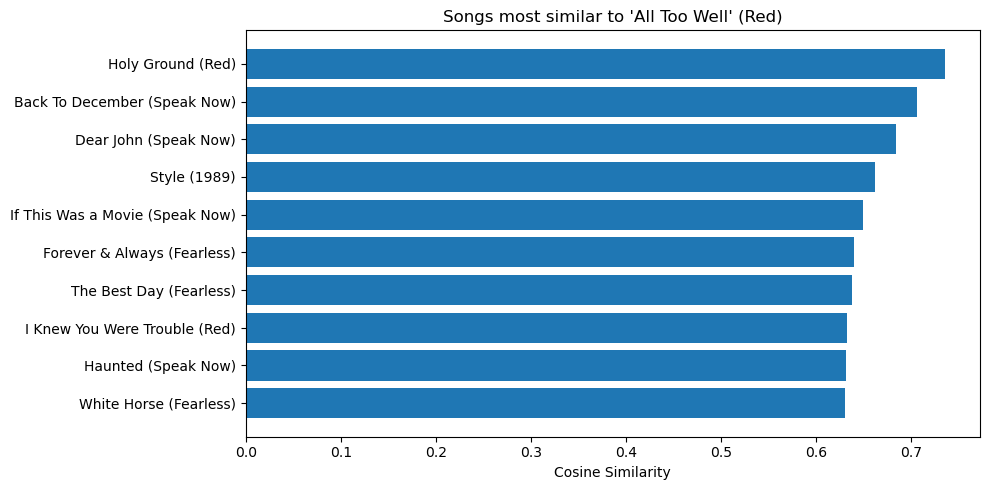

,album,track_title,year,similarity
0,Red,Holy Ground,2012,0.735622
1,Speak Now,Back To December,2010,0.706130
2,Speak Now,Dear John,2010,0.684138
3,1989,Style,2014,0.661900
4,Speak Now,If This Was a Movie,2010,0.649663
5,Fearless,Forever & Always,2008,0.639650
6,Fearless,The Best Day,2008,0.637712
7,Red,I Knew You Were Trouble,2012,0.632776
8,Speak Now,Haunted,2010,0.631968
9,Fearless,White Horse,2008,0.630566


In [47]:
# Example: similar songs for a selected track
plot_similar_songs(track_title='All Too Well', top_k=10, exclude_same_album=False)


## Similarity Network Graph

This graph-based view turns pairwise song similarity into a network, making it easier to see clusters of related tracks and bridges between albums or eras.


### Similarity Network Graph

Visualize a local lyric-similarity network with:
- center node: query song
- surrounding nodes: top-k nearest songs
- edges between neighbors when they are also highly similar


In [48]:
import networkx as nx

def plot_similarity_network(track_title, album=None, top_k=12, neighbor_edge_threshold=0.55,
                            exclude_same_album=False, seed=42):
    q = song_embed_df[song_embed_df['track_title'].str.lower() == track_title.lower()]
    if album is not None:
        q = q[q['album'].str.lower() == album.lower()]
    if q.empty:
        raise ValueError('No matching song found. Check title/album spelling.')

    q_idx = q.index[0]
    scores = sim_matrix[q_idx].copy()

    if exclude_same_album:
        same_album_mask = song_embed_df['album'] == song_embed_df.loc[q_idx, 'album']
        scores[same_album_mask.values] = -1

    top_idx = np.argsort(scores)[-top_k:][::-1]
    nodes = [q_idx] + [int(i) for i in top_idx]

    G = nx.Graph()

    def node_label(i):
        return f"{song_embed_df.loc[i, 'track_title']}\n({song_embed_df.loc[i, 'album']})"

    # Add nodes
    for i in nodes:
        G.add_node(i,
                   label=node_label(i),
                   album=song_embed_df.loc[i, 'album'])

    # Connect query to each neighbor
    for i in top_idx:
        w = float(sim_matrix[q_idx, i])
        G.add_edge(q_idx, int(i), weight=max(0.0, w))

    # Add neighbor-neighbor edges if sufficiently similar
    neighbor_list = [int(i) for i in top_idx]
    for a in range(len(neighbor_list)):
        for b in range(a + 1, len(neighbor_list)):
            i, j = neighbor_list[a], neighbor_list[b]
            w = float(sim_matrix[i, j])
            if w >= neighbor_edge_threshold:
                G.add_edge(i, j, weight=w)

    # Album colors
    albums = sorted(song_embed_df.loc[nodes, 'album'].unique())
    cmap = plt.cm.get_cmap('tab20', max(3, len(albums)))
    album_to_color = {alb: cmap(i) for i, alb in enumerate(albums)}

    node_colors = [album_to_color[G.nodes[n]['album']] for n in G.nodes()]
    node_sizes = [1100 if n == q_idx else 600 for n in G.nodes()]

    edge_widths = [1.0 + 5.0 * G.edges[e]['weight'] for e in G.edges()]

    pos = nx.spring_layout(G, seed=seed, k=0.9/np.sqrt(max(1, G.number_of_nodes())))

    fig, ax = plt.subplots(figsize=(12, 9))
    nx.draw_networkx_edges(G, pos, alpha=0.35, width=edge_widths, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax)
    nx.draw_networkx_labels(
        G,
        pos,
        labels={n: G.nodes[n]['label'] for n in G.nodes()},
        font_size=8,
        ax=ax
    )

    # Album legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=alb,
                          markerfacecolor=album_to_color[alb], markersize=8) for alb in albums]
    ax.legend(handles=handles, title='Album', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    ax.set_title(
        f"Lyric Similarity Network: '{song_embed_df.loc[q_idx, 'track_title']}' ({song_embed_df.loc[q_idx, 'album']})"
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    out = song_embed_df.loc[top_idx, ['album', 'track_title', 'year']].copy()
    out['similarity_to_query'] = [float(sim_matrix[q_idx, i]) for i in top_idx]
    return out.reset_index(drop=True)


/var/folders/hv/6pn1grfs043c6x9_z04cgv5h0000gn/T/ipykernel_8853/3268576118.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(3, len(albums)))


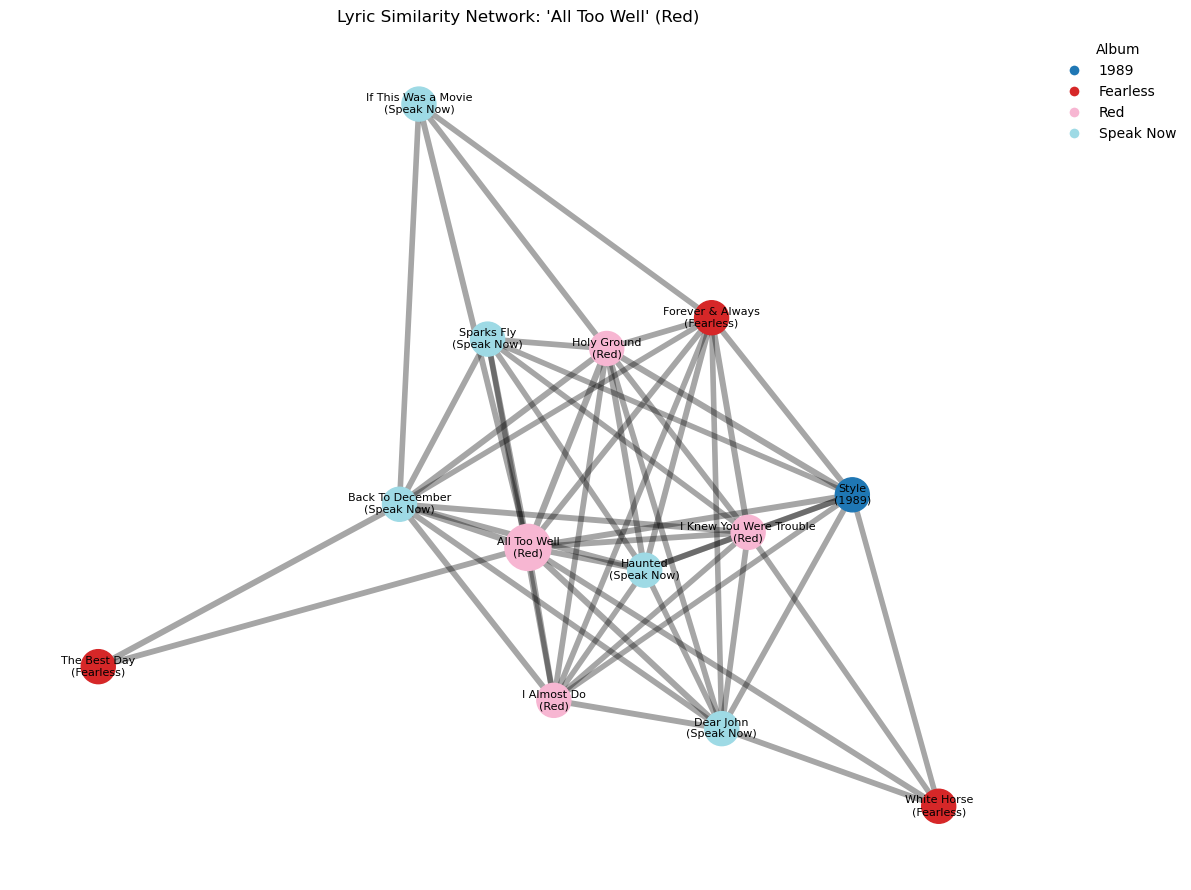

,album,track_title,year,similarity_to_query
0,Red,Holy Ground,2012,0.735622
1,Speak Now,Back To December,2010,0.706130
2,Speak Now,Dear John,2010,0.684138
3,1989,Style,2014,0.661900
4,Speak Now,If This Was a Movie,2010,0.649663
5,Fearless,Forever & Always,2008,0.639650
6,Fearless,The Best Day,2008,0.637712
7,Red,I Knew You Were Trouble,2012,0.632776
8,Speak Now,Haunted,2010,0.631968
9,Fearless,White Horse,2008,0.630566


In [49]:
# Example network graph
plot_similarity_network(
    track_title='All Too Well',
    top_k=12,
    neighbor_edge_threshold=0.58,
    exclude_same_album=False
)


## Conclusion

Taken together, the notebook shows how Taylor Swift lyrics can be studied from several complementary angles: word choice over time, narrative perspective, setting imagery, network structure, topical composition, and predictive modeling. The combination of descriptive and machine-learning methods makes it possible to trace both interpretable thematic shifts and broader structural similarities across the discography.
